# Phase 3 — Autoencoder: Build, Train, Evaluate (Interactive)

This notebook covers all of Phase 3 (building the model, an experimental
single training run, the full 5-seed sweep, threshold calibration,
visualization, and the ablation comparison) in one place, cell by cell.
It runs on top of Phase 2's output (`features_all_windows.csv`) and the
official train/val/test split (`03_phase3_splits/`) — this replaces the
old `faz3_autoencoder.py` script.

## 1. Setup — imports and data loading

Loads the Phase 2 feature matrix and the official train/val/test split
(seed=1, signature-grouped, leakage-free scaler).

In [1]:
import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import roc_auc_score, roc_curve, precision_score, recall_score, f1_score, accuracy_score

BASE = Path.cwd()
FEAT_DIR = Path.home() / "Desktop" / "NIDS" / "data" / "ids-dataset-features"
SPLIT_DIR = BASE / "03_phase3_splits"
MODEL_DIR = BASE / "04_phase3_models"
RESULTS_DIR = BASE / "05_phase3_results"
MODEL_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)

print(f"TensorFlow {tf.__version__}, GPU: {tf.config.list_physical_devices('GPU')}")

features = pd.read_csv(FEAT_DIR / "features_all_windows.csv")
train_idx = pd.read_csv(SPLIT_DIR / "train_indices.csv")["row_index"].values
val_idx = pd.read_csv(SPLIT_DIR / "val_indices.csv")["row_index"].values
test_idx = pd.read_csv(SPLIT_DIR / "test_indices.csv")["row_index"].values

train_df = features.iloc[train_idx].reset_index(drop=True)
val_df = features.iloc[val_idx].reset_index(drop=True)
test_df = features.iloc[test_idx].reset_index(drop=True)

META_COLS = ["is_attack", "actual_attack_pct", "window_id", "ts"]
CONN_STATE_COLS = ["conn_state_REJ", "conn_state_RSTO", "conn_state_S1", "conn_state_SF"]
FULL_COLS = [c for c in features.columns if c not in META_COLS]
NO_CS_COLS = [c for c in FULL_COLS if c not in CONN_STATE_COLS]

assert (train_df["is_attack"] == 0).all(), "train split must be 100% benign"
print(f"train={len(train_df)} (all benign), val={len(val_df)}, test={len(test_df)}")
print(f"full_features: {len(FULL_COLS)} columns, no_conn_state: {len(NO_CS_COLS)} columns")

NAIVE_BASELINE = {"precision": 0.9908, "recall": 0.6656, "f1": 0.7963}

TensorFlow 2.21.0, GPU: []
train=23274 (all benign), val=6576, test=6581
full_features: 18 columns, no_conn_state: 14 columns


## 2. Model architecture

`Input(N) -> Dense(16, relu, L2) -> Dropout(0.15) -> Dense(8, relu, L2,
bottleneck) -> Dropout(0.15) -> Dense(16, relu, L2) -> Dense(N, linear)`

Dropout + L2 regularization are added against overfitting risk, given
the small dataset (train ~23K rows).

In [2]:
def build_model(n_features, seed):
    tf.keras.utils.set_random_seed(seed)
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(n_features,)),
        tf.keras.layers.Dense(16, activation="relu", kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
        tf.keras.layers.Dropout(0.15),
        tf.keras.layers.Dense(8, activation="relu", kernel_regularizer=tf.keras.regularizers.l2(1e-4), name="bottleneck"),
        tf.keras.layers.Dropout(0.15),
        tf.keras.layers.Dense(16, activation="relu", kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
        tf.keras.layers.Dense(n_features, activation="linear"),
    ])
    model.compile(optimizer="adam", loss="mse")
    return model

demo_model = build_model(len(FULL_COLS), seed=0)
demo_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 18)             │           306 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 890 (3.48 KB)

 Trainable params: 890 (3.48 KB)

 Non-trainable params: 0 (0.00 B)

## 3. Experimental training run (single model, visualized)

First we train a SINGLE model (full_features, seed=0) and visualize how
the training/validation loss converges — a sanity check that the
architecture and early-stopping settings are reasonable. `val_loss` is
computed ONLY on benign val flows (attack flows are never used for loss
monitoring, only for threshold calibration later).

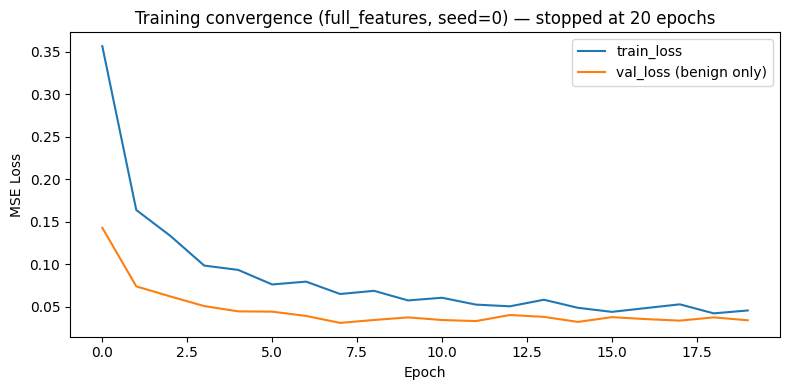

Final train_loss: 0.0458, final val_loss: 0.0342


In [3]:
X_train_demo = train_df[FULL_COLS].values.astype("float32")
X_val_benign_demo = val_df.loc[val_df["is_attack"] == 0, FULL_COLS].values.astype("float32")

early_stop_demo = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=12, restore_best_weights=True)
history_demo = demo_model.fit(
    X_train_demo, X_train_demo,
    validation_data=(X_val_benign_demo, X_val_benign_demo),
    epochs=200, batch_size=128, shuffle=True,
    callbacks=[early_stop_demo], verbose=0,
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history_demo.history["loss"], label="train_loss")
ax.plot(history_demo.history["val_loss"], label="val_loss (benign only)")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.set_title(f"Training convergence (full_features, seed=0) — stopped at {len(history_demo.history['loss'])} epochs")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Final train_loss: {history_demo.history['loss'][-1]:.4f}, final val_loss: {history_demo.history['val_loss'][-1]:.4f}")

## 4. Full sweep: 5 seeds × 2 variants (full_features, no_conn_state)

The actual Phase 3 experiment: for each feature-set variant, train from
scratch with 5 different weight-initialization seeds, calibrate
thresholds, and evaluate on the test set. Models are saved under
`04_phase3_models/`, metrics under `05_phase3_results/` (same output
format the old script used).

In [4]:
def reconstruction_error(model, X):
    recon = model.predict(X, verbose=0)
    return np.mean(np.square(X - recon), axis=1)


def evaluate_at_threshold(y_true, errors, threshold):
    y_pred = (errors > threshold).astype(int)
    return {
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "threshold": float(threshold),
    }


def run_variant(variant_name, cols, seeds=(0, 1, 2, 3, 4)):
    n_features = len(cols)
    X_train = train_df[cols].values.astype("float32")
    val_benign_mask = val_df["is_attack"] == 0
    X_val_benign = val_df.loc[val_benign_mask, cols].values.astype("float32")
    X_val_all = val_df[cols].values.astype("float32")
    y_val = val_df["is_attack"].values
    X_test = test_df[cols].values.astype("float32")
    y_test = test_df["is_attack"].values

    model_dir = MODEL_DIR / variant_name
    model_dir.mkdir(parents=True, exist_ok=True)
    results_dir = RESULTS_DIR / variant_name
    results_dir.mkdir(parents=True, exist_ok=True)

    seed_metrics = []
    for seed in seeds:
        t0 = time.time()
        model = build_model(n_features, seed)
        early_stop = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=12, restore_best_weights=True)
        history = model.fit(
            X_train, X_train, validation_data=(X_val_benign, X_val_benign),
            epochs=200, batch_size=128, shuffle=True, callbacks=[early_stop], verbose=0,
        )
        train_time = time.time() - t0
        model.save(model_dir / f"autoencoder_seed{seed}.keras")

        val_errors_benign = reconstruction_error(model, X_val_benign)
        val_errors_all = reconstruction_error(model, X_val_all)
        test_errors = reconstruction_error(model, X_test)

        thr_pctl = float(np.percentile(val_errors_benign, 95))
        fpr, tpr, roc_thresholds = roc_curve(y_val, val_errors_all)
        thr_youden = float(roc_thresholds[np.argmax(tpr - fpr)])

        test_auc = float(roc_auc_score(y_test, test_errors))
        metrics_pctl = evaluate_at_threshold(y_test, test_errors, thr_pctl)
        metrics_youden = evaluate_at_threshold(y_test, test_errors, thr_youden)

        result = {
            "seed": seed, "variant": variant_name, "n_features": n_features,
            "train_time_sec": round(train_time, 2), "epochs_run": len(history.history["loss"]),
            "final_train_loss": float(history.history["loss"][-1]),
            "final_val_loss": float(history.history["val_loss"][-1]),
            "test_auc": test_auc,
            "threshold_pctl95": metrics_pctl, "threshold_youden": metrics_youden,
        }
        seed_metrics.append(result)
        json.dump(result, open(results_dir / f"seed{seed}_metrics.json", "w"), indent=2)
        print(f"[{variant_name}] seed={seed}: epochs={result['epochs_run']} time={train_time:.1f}s "
              f"AUC={test_auc:.4f} pctl95_F1={metrics_pctl['f1']:.4f}")

    def agg(fn):
        vals = [fn(m) for m in seed_metrics]
        return {"mean": float(np.mean(vals)), "std": float(np.std(vals))}

    summary = {
        "variant": variant_name, "n_features": n_features, "n_seeds": len(seeds),
        "test_auc": agg(lambda m: m["test_auc"]),
        "train_time_sec": agg(lambda m: m["train_time_sec"]),
        "epochs_run": agg(lambda m: m["epochs_run"]),
        "threshold_pctl95": {k: agg(lambda m, k=k: m["threshold_pctl95"][k]) for k in ["precision", "recall", "f1", "accuracy"]},
        "threshold_youden": {k: agg(lambda m, k=k: m["threshold_youden"][k]) for k in ["precision", "recall", "f1", "accuracy"]},
    }
    json.dump(summary, open(RESULTS_DIR / f"{variant_name}_summary.json", "w"), indent=2)
    return summary, seed_metrics


full_summary, full_seed_metrics = run_variant("full_features", FULL_COLS)
no_cs_summary, no_cs_seed_metrics = run_variant("no_conn_state", NO_CS_COLS)

ablation = {"full_features": full_summary, "no_conn_state": no_cs_summary, "naive_baseline": NAIVE_BASELINE}
json.dump(ablation, open(RESULTS_DIR / "ablation_comparison.json", "w"), indent=2)
print("\nAll models and results saved.")

[full_features] seed=0: epochs=20 time=2.6s AUC=0.9479 pctl95_F1=0.8618


[full_features] seed=1: epochs=36 time=4.3s AUC=0.9390 pctl95_F1=0.8709


[full_features] seed=2: epochs=64 time=7.2s AUC=0.9304 pctl95_F1=0.8599


[full_features] seed=3: epochs=53 time=6.0s AUC=0.9575 pctl95_F1=0.8515


[full_features] seed=4: epochs=32 time=3.8s AUC=0.9568 pctl95_F1=0.8680


[no_conn_state] seed=0: epochs=20 time=2.6s AUC=0.9356 pctl95_F1=0.8456


[no_conn_state] seed=1: epochs=47 time=5.3s AUC=0.9141 pctl95_F1=0.8779


[no_conn_state] seed=2: epochs=36 time=4.2s AUC=0.9538 pctl95_F1=0.8617


[no_conn_state] seed=3: epochs=44 time=5.0s AUC=0.9354 pctl95_F1=0.8696


[no_conn_state] seed=4: epochs=25 time=3.3s AUC=0.9318 pctl95_F1=0.8659

All models and results saved.


## 5. 5-seed results tables

Per-seed metrics, then 5-seed mean±std summaries (full_features vs
no_conn_state).

In [5]:
def to_rows(seed_metrics, variant):
    return [{
        "seed": m["seed"], "variant": variant, "test_auc": m["test_auc"],
        "precision_pctl95": m["threshold_pctl95"]["precision"],
        "recall_pctl95": m["threshold_pctl95"]["recall"],
        "f1_pctl95": m["threshold_pctl95"]["f1"],
    } for m in seed_metrics]

per_seed = pd.DataFrame(to_rows(full_seed_metrics, "full_features") + to_rows(no_cs_seed_metrics, "no_conn_state"))
per_seed

,seed,variant,test_auc,precision_pctl95,recall_pctl95,f1_pctl95
0,0,full_features,0.947894,0.932152,0.801366,0.861825
1,1,full_features,0.938992,0.961881,0.795586,0.870866
2,2,full_features,0.930442,0.927616,0.801366,0.859882
3,3,full_features,0.957495,0.908279,0.801366,0.851480
4,4,full_features,0.956846,0.946617,0.801366,0.867957
5,0,no_conn_state,0.935600,0.902265,0.795586,0.845574
6,1,no_conn_state,0.914096,0.979301,0.795586,0.877936
7,2,no_conn_state,0.953787,0.939789,0.795586,0.861696
8,3,no_conn_state,0.935436,0.958835,0.795586,0.869615
9,4,no_conn_state,0.931790,0.949812,0.795586,0.865885


In [6]:
def summary_row(s):
    return {
        "n_features": s["n_features"],
        "test_auc_mean": s["test_auc"]["mean"], "test_auc_std": s["test_auc"]["std"],
        "precision_mean": s["threshold_pctl95"]["precision"]["mean"], "precision_std": s["threshold_pctl95"]["precision"]["std"],
        "recall_mean": s["threshold_pctl95"]["recall"]["mean"], "recall_std": s["threshold_pctl95"]["recall"]["std"],
        "f1_mean": s["threshold_pctl95"]["f1"]["mean"], "f1_std": s["threshold_pctl95"]["f1"]["std"],
    }

summary_table = pd.DataFrame({"full_features": summary_row(full_summary), "no_conn_state": summary_row(no_cs_summary)}).T
summary_table

,n_features,test_auc_mean,test_auc_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std
full_features,18.0,0.946334,0.010430,0.935309,0.018076,0.800210,0.002312,0.862402,0.006760
no_conn_state,14.0,0.934142,0.012626,0.946000,0.025454,0.795586,0.000000,0.864141,0.010715


## 6. Reconstruction error visualization

The core visual evidence for the anomaly-detection thesis: benign flows
should reconstruct with low error, attack flows with high error. Shown
for the seed=0 full_features model on the test set.

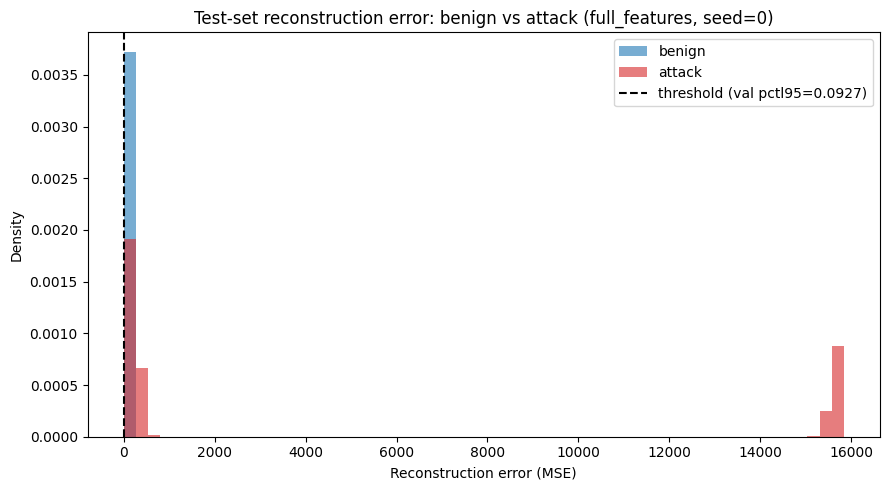

Benign test error: mean=0.02420, median=0.00721
Attack test error: mean=5273.49561, median=287.25766


In [7]:
model_path = MODEL_DIR / "full_features" / "autoencoder_seed0.keras"
best_model = tf.keras.models.load_model(model_path)

X_test_full = test_df[FULL_COLS].values.astype("float32")
y_test = test_df["is_attack"].values
test_errors = reconstruction_error(best_model, X_test_full)

X_val_benign_full = val_df.loc[val_df["is_attack"] == 0, FULL_COLS].values.astype("float32")
val_benign_errors = reconstruction_error(best_model, X_val_benign_full)
threshold_pctl95 = np.percentile(val_benign_errors, 95)

benign_errors_test = test_errors[y_test == 0]
attack_errors_test = test_errors[y_test == 1]

fig, ax = plt.subplots(figsize=(9, 5))
bins = np.linspace(0, np.percentile(test_errors, 99), 60)
ax.hist(benign_errors_test, bins=bins, alpha=0.6, label="benign", color="tab:blue", density=True)
ax.hist(attack_errors_test, bins=bins, alpha=0.6, label="attack", color="tab:red", density=True)
ax.axvline(threshold_pctl95, color="black", linestyle="--", label=f"threshold (val pctl95={threshold_pctl95:.4f})")
ax.set_xlabel("Reconstruction error (MSE)")
ax.set_ylabel("Density")
ax.set_title("Test-set reconstruction error: benign vs attack (full_features, seed=0)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Benign test error: mean={benign_errors_test.mean():.5f}, median={np.median(benign_errors_test):.5f}")
print(f"Attack test error: mean={attack_errors_test.mean():.5f}, median={np.median(attack_errors_test):.5f}")

## 7. ROC curve

ROC curve and AUC for the test set (seed=0, full_features).

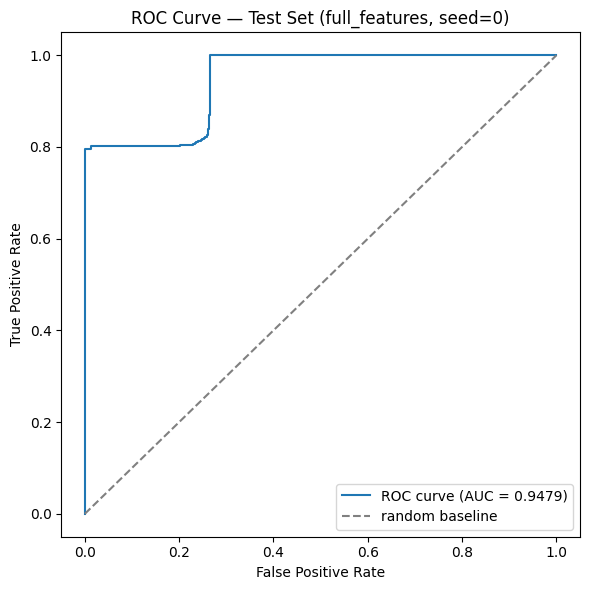

Test AUC (seed=0, full_features): 0.9479


In [8]:
fpr, tpr, _ = roc_curve(y_test, test_errors)
auc_value = roc_auc_score(y_test, test_errors)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(fpr, tpr, color="tab:blue", label=f"ROC curve (AUC = {auc_value:.4f})")
ax.plot([0, 1], [0, 1], color="gray", linestyle="--", label="random baseline")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — Test Set (full_features, seed=0)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

print(f"Test AUC (seed=0, full_features): {auc_value:.4f}")

## 8. Ablation comparison

`full_features` (with conn_state) vs `no_conn_state` (conn_state
removed), 5-seed mean±std, with the naive baseline as a reference
line.

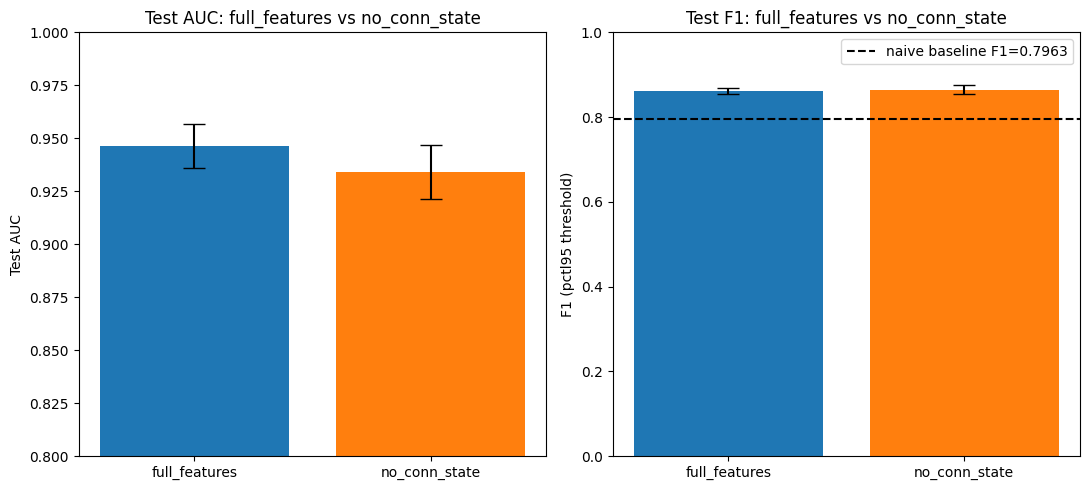

AUC delta (full - no_conn_state): +0.0122
F1 delta (full - no_conn_state):  -0.0017


In [9]:
variants = ["full_features", "no_conn_state"]
auc_means = [full_summary["test_auc"]["mean"], no_cs_summary["test_auc"]["mean"]]
auc_stds = [full_summary["test_auc"]["std"], no_cs_summary["test_auc"]["std"]]
f1_means = [full_summary["threshold_pctl95"]["f1"]["mean"], no_cs_summary["threshold_pctl95"]["f1"]["mean"]]
f1_stds = [full_summary["threshold_pctl95"]["f1"]["std"], no_cs_summary["threshold_pctl95"]["f1"]["std"]]

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
axes[0].bar(variants, auc_means, yerr=auc_stds, capsize=8, color=["tab:blue", "tab:orange"])
axes[0].set_ylabel("Test AUC")
axes[0].set_title("Test AUC: full_features vs no_conn_state")
axes[0].set_ylim(0.8, 1.0)

axes[1].bar(variants, f1_means, yerr=f1_stds, capsize=8, color=["tab:blue", "tab:orange"])
axes[1].axhline(NAIVE_BASELINE["f1"], color="black", linestyle="--", label=f"naive baseline F1={NAIVE_BASELINE['f1']}")
axes[1].set_ylabel("F1 (pctl95 threshold)")
axes[1].set_title("Test F1: full_features vs no_conn_state")
axes[1].set_ylim(0.0, 1.0)
axes[1].legend()
plt.tight_layout()
plt.show()

print(f"AUC delta (full - no_conn_state): {auc_means[0] - auc_means[1]:+.4f}")
print(f"F1 delta (full - no_conn_state):  {f1_means[0] - f1_means[1]:+.4f}")

## 9. Summary table

| Model | Precision | Recall | F1 | Test AUC |
|---|---|---|---|---|
| Naive baseline (`conn_state != SF`) | 0.9908 | 0.6656 | 0.7963 | — |
| Autoencoder — full_features (pctl95) | *(see table above)* | | | |
| Autoencoder — no_conn_state (pctl95) | *(see table above)* | | | |

**Conclusion:** both autoencoder variants beat the naive baseline on F1
by a wide margin (the gain comes from recall), and the small gap
between the full and ablated variants shows the model is not simply
relying on conn_state as a shortcut — it learns real, independent
signal.

## 10. Export human-readable model files

`.keras` files are zip archives — unreadable when opened directly in a
text editor. This exports, next to each `.keras` file, a JSON
architecture dump (`*.json`) and a plain-text layer summary
(`*_readable.txt`), so every model in `04_phase3_models/` can be
inspected without loading it in Python.

In [10]:
import io

for variant_dir in ["full_features", "no_conn_state"]:
    for keras_path in sorted((MODEL_DIR / variant_dir).glob("*.keras")):
        m = tf.keras.models.load_model(keras_path)

        json_path = keras_path.with_suffix(".json")
        json_path.write_text(json.dumps(m.get_config(), indent=2, default=str))

        buf = io.StringIO()
        m.summary(print_fn=lambda line: buf.write(line + "\n"))
        txt_lines = [
            f"Model file: {keras_path.name}",
            f"Variant: {variant_dir}",
            f"Input size (feature count): {m.input_shape[-1]}",
            "(Full parameter/layer breakdown below - 'Trainable params' are the"
            " model's own weights, 'Optimizer params' is Adam's extra training-time"
            " state, not part of the architecture.)",
            "",
            "--- Layer-by-layer architecture ---",
            buf.getvalue(),
            "--- Layer details (activation, output shape, param count) ---",
        ]
        for layer in m.layers:
            cfg = layer.get_config()
            txt_lines.append(
                f"  {layer.name:20s} | type={layer.__class__.__name__:12s} | "
                f"units={cfg.get('units', '-')} | activation={cfg.get('activation', '-')} | "
                f"output_shape={layer.output.shape if hasattr(layer, 'output') else '-'} | "
                f"params={layer.count_params()}"
            )
        keras_path.with_name(keras_path.stem + "_readable.txt").write_text("\n".join(txt_lines))
        print(f"OK  {variant_dir}/{keras_path.name} -> .json + _readable.txt")

print("\nDone.")

OK  full_features/autoencoder_seed0.keras -> .json + _readable.txt


OK  full_features/autoencoder_seed1.keras -> .json + _readable.txt


OK  full_features/autoencoder_seed2.keras -> .json + _readable.txt


OK  full_features/autoencoder_seed3.keras -> .json + _readable.txt


OK  full_features/autoencoder_seed4.keras -> .json + _readable.txt


OK  no_conn_state/autoencoder_seed0.keras -> .json + _readable.txt


OK  no_conn_state/autoencoder_seed1.keras -> .json + _readable.txt


OK  no_conn_state/autoencoder_seed2.keras -> .json + _readable.txt


OK  no_conn_state/autoencoder_seed3.keras -> .json + _readable.txt


OK  no_conn_state/autoencoder_seed4.keras -> .json + _readable.txt

Done.
